In [29]:
# Import libraries
import numpy as np
import hdbscan
import pandas as pd
from sklearn import manifold, cluster
from matplotlib import pyplot as plt
import umap
import umap.plot
from pathlib import Path
from sklearn.metrics import silhouette_score
from itertools import product
from sklearn_extra.cluster import KMedoids

In [3]:
repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / '.git').exists())
DIST_FILE = repo_root / 'analysis/mash/pairwise_distances_filtered.npy'
SAMPLE_FILE = repo_root / 'analysis/samples_for_clustering.txt'


In [4]:
# Load distance matrix, convert to float64
distance_matrix = np.load(DIST_FILE)
distance_matrix = distance_matrix.astype(np.float64)
print("Matrix loaded!")

# Print shape to verify
print(distance_matrix.shape)

Matrix loaded!
(18952, 18952)


In [5]:
import numpy as np

D = distance_matrix

print("=== BASIC INFO ===")
print("Shape:", D.shape)
print("Dtype:", D.dtype)

# 1. Must be square
print("\n=== SQUARE CHECK ===")
is_square = D.shape[0] == D.shape[1]
print("Is square:", is_square)

# 2. Symmetry check
print("\n=== SYMMETRY CHECK ===")
sym_diff = np.abs(D - D.T)
print("Max symmetry difference:", np.max(sym_diff))
print("Is symmetric (approx):", np.allclose(D, D.T, atol=1e-8))

# 3. Diagonal check
print("\n=== DIAGONAL CHECK ===")
diag = np.diag(D)
print("Min diagonal:", diag.min())
print("Max diagonal:", diag.max())
print("All zeros on diagonal:", np.allclose(diag, 0, atol=1e-8))

# 4. Non-negativity check
print("\n=== NON-NEGATIVITY CHECK ===")
print("Min value in matrix:", D.min())
print("Any negative values:", np.any(D < 0))

# 5. Value range check
print("\n=== VALUE RANGE ===")
print("Min:", D.min())
print("Max:", D.max())

# 6. NaN / Inf check
print("\n=== NaN / INF CHECK ===")
print("Any NaN:", np.isnan(D).any())
print("Any Inf:", np.isinf(D).any())

# 7. Identity sanity (distance to self should be smallest in row)
print("\n=== SELF-DISTANCE CHECK ===")
row_min_indices = np.argmin(D, axis=1)
self_is_min = np.mean(row_min_indices == np.arange(D.shape[0]))
print("Fraction where self is closest point:", self_is_min)

# 8. Quick scale heuristic for epsilon tuning
print("\n=== DISTANCE SCALE STATS ===")
flat = D[np.triu_indices(D.shape[0], k=1)]
print("Median pairwise distance:", np.median(flat))
print("90th percentile:", np.percentile(flat, 90))
print("95th percentile:", np.percentile(flat, 95))
print("99th percentile:", np.percentile(flat, 99))

=== BASIC INFO ===
Shape: (18952, 18952)
Dtype: float64

=== SQUARE CHECK ===
Is square: True

=== SYMMETRY CHECK ===
Max symmetry difference: 0.0
Is symmetric (approx): True

=== DIAGONAL CHECK ===
Min diagonal: 0.0
Max diagonal: 0.0
All zeros on diagonal: True

=== NON-NEGATIVITY CHECK ===
Min value in matrix: 0.0
Any negative values: False

=== VALUE RANGE ===
Min: 0.0
Max: 0.0488663986325264

=== NaN / INF CHECK ===
Any NaN: False
Any Inf: False

=== SELF-DISTANCE CHECK ===
Fraction where self is closest point: 1.0

=== DISTANCE SCALE STATS ===
Median pairwise distance: 0.010133299976587296
90th percentile: 0.03513360023498535
95th percentile: 0.03563379868865013
99th percentile: 0.03644239902496338


In [14]:
# Test HDBSCAN parameters and evaluate silhouette scores
import numpy as np
import hdbscan
from sklearn.metrics import silhouette_score
from itertools import product

# Define parameter grids
min_cluster_sizes = [10, 25, 50, 100]
min_samples_values = [1, 5, 10, 25]
epsilons = [0.0001, 0.001, 0.01, 0.1]

best_score = -1
best_params = {}
results = []

for min_cluster_size, min_samples, epsilon in product(min_cluster_sizes, min_samples_values, epsilons):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        cluster_selection_epsilon=epsilon,
        metric='precomputed'
    )
    labels = clusterer.fit_predict(distance_matrix)

    # Skip if all points are noise (-1) or only one cluster found
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        continue

    # Silhouette score requires at least 2 clusters and no all-noise result
    try:
        score = silhouette_score(distance_matrix, labels, metric='precomputed')
    except ValueError:
        continue

    results.append({
        'min_cluster_size': min_cluster_size,
        'min_samples': min_samples,
        'epsilon': epsilon,
        'n_clusters': n_clusters,
        'noise_points': np.sum(labels == -1),
        'silhouette_score': score
    })

    if score > best_score:
        best_score = score
        best_params = {
            'min_cluster_size': min_cluster_size,
            'min_samples': min_samples,
            'cluster_selection_epsilon': epsilon
        }

# Sort and display results
results.sort(key=lambda x: x['silhouette_score'], reverse=True)
print(f"Best silhouette score: {best_score:.4f}")
print(f"Best params: {best_params}")
print(f"\nTop 10 combinations:")
print(f"{'min_cluster_size':>16} {'min_samples':>12} {'epsilon':>10} {'n_clusters':>10} {'noise_pts':>10} {'score':>8}")
print("-" * 70)
for r in results[:10]:
    print(f"{r['min_cluster_size']:>16} {r['min_samples']:>12} {r['epsilon']:>10.4f} "
          f"{r['n_clusters']:>10} {r['noise_points']:>10} {r['silhouette_score']:>8.4f}")

# Re-fit with best params
best_clusterer = hdbscan.HDBSCAN(metric='precomputed', **best_params)
best_clusterer.fit(distance_matrix)

Best silhouette score: 0.7581
Best params: {'min_cluster_size': 10, 'min_samples': 1, 'cluster_selection_epsilon': 0.1}

Top 10 combinations:
min_cluster_size  min_samples    epsilon n_clusters  noise_pts    score
----------------------------------------------------------------------
              10            1     0.1000          2          1   0.7581
              10            5     0.1000          2          1   0.7581
              10           10     0.1000          2          1   0.7581
              10           25     0.1000          2          1   0.7581
              25            1     0.1000          2          1   0.7581
              25            5     0.1000          2          1   0.7581
              25           10     0.1000          2          1   0.7581
              25           25     0.1000          2          1   0.7581
              50            1     0.1000          2          1   0.7581
              50            5     0.1000          2          1   0.

,min_cluster_size,10
,min_samples,1
,cluster_selection_epsilon,0.1
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'precomputed'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


In [15]:
for r in results[:]:
    print(f"{r['min_cluster_size']:>16} {r['min_samples']:>12} {r['epsilon']:>10.4f} "
          f"{r['n_clusters']:>10} {r['noise_points']:>10} {r['silhouette_score']:>8.4f}")

              10            1     0.1000          2          1   0.7581
              10            5     0.1000          2          1   0.7581
              10           10     0.1000          2          1   0.7581
              10           25     0.1000          2          1   0.7581
              25            1     0.1000          2          1   0.7581
              25            5     0.1000          2          1   0.7581
              25           10     0.1000          2          1   0.7581
              25           25     0.1000          2          1   0.7581
              50            1     0.1000          2          1   0.7581
              50            5     0.1000          2          1   0.7581
              50           10     0.1000          2          1   0.7581
              50           25     0.1000          2          1   0.7581
             100            1     0.1000          2          1   0.7581
             100            5     0.1000          2          1  

In [16]:
# Create clusterer object
clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=1, cluster_selection_epsilon=0.001, metric='precomputed')

# Fit the clusterer to the data
clusterer.fit(distance_matrix)

,min_cluster_size,25
,min_samples,1
,cluster_selection_epsilon,0.001
,cluster_selection_persistence,0.0
,max_cluster_size,0
,metric,'precomputed'
,alpha,1.0
,p,None
,algorithm,'best'
,leaf_size,40
,memory,Memory(location=None)


In [17]:
# Print the number of clusters found
print(f"Number of clusters found: {max(clusterer.labels_)}")
# Print number of noise points
print(f"Number of noise points: {np.sum(clusterer.labels_ == -1)}")
# Print number of points in each cluster
print(f"Number of points in each cluster: {np.bincount(clusterer.labels_[clusterer.labels_ >= 0])}")

Number of clusters found: 63
Number of noise points: 584
Number of points in each cluster: [  56  242   33   35   74   56   30   58  794   30 1611  103  197   45
   44   35   49  134   94 3164  114   42   61   47   97   25  113  360
  104  207   66  173   96   29  110   95  109  277  254   84   48   34
  498  312 1240   58  278   41  209   62 1262  377  165   54   27  310
   34   98   59  711  177  119 2816   32]


In [18]:
# For each cluster, find the point in the cluster with the smallest distance to other points in the cluster
cluster_centers = []
for cluster_label in np.unique(clusterer.labels_):
    if cluster_label == -1:  # Skip noise points
        continue
    cluster_points = np.where(clusterer.labels_ == cluster_label)[0]
    distances_to_cluster = distance_matrix[cluster_points][:, cluster_points]
    center_index = cluster_points[np.argmin(np.sum(distances_to_cluster, axis=1))]
    cluster_centers.append(center_index)

print(f"Cluster centers: {cluster_centers}")

Cluster centers: [np.int64(1877), np.int64(1788), np.int64(8145), np.int64(3379), np.int64(3751), np.int64(14558), np.int64(15413), np.int64(16152), np.int64(661), np.int64(2551), np.int64(17980), np.int64(18145), np.int64(7859), np.int64(18554), np.int64(18358), np.int64(12120), np.int64(4552), np.int64(18507), np.int64(17218), np.int64(15930), np.int64(13487), np.int64(4534), np.int64(8660), np.int64(4758), np.int64(11751), np.int64(18524), np.int64(83), np.int64(17226), np.int64(15174), np.int64(14181), np.int64(18527), np.int64(11465), np.int64(15495), np.int64(5371), np.int64(15393), np.int64(10684), np.int64(16366), np.int64(4105), np.int64(17800), np.int64(5985), np.int64(18241), np.int64(4852), np.int64(8563), np.int64(6344), np.int64(11401), np.int64(13448), np.int64(14984), np.int64(7574), np.int64(13264), np.int64(15402), np.int64(14571), np.int64(5936), np.int64(16526), np.int64(10469), np.int64(8531), np.int64(1529), np.int64(3176), np.int64(3371), np.int64(1350), np.int64

In [27]:
# Initialize UMAP object
umap_model = umap.UMAP(n_components=2, n_neighbors=500, min_dist=0.1, metric='precomputed', random_state=42)

# Fit the UMAP model to the distance matrix
u = umap_model.fit_transform(distance_matrix)

/project/60004/ybrooks/lineage_specific_markers/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/project/60004/ybrooks/lineage_specific_markers/envs/jupyter/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Axes: >

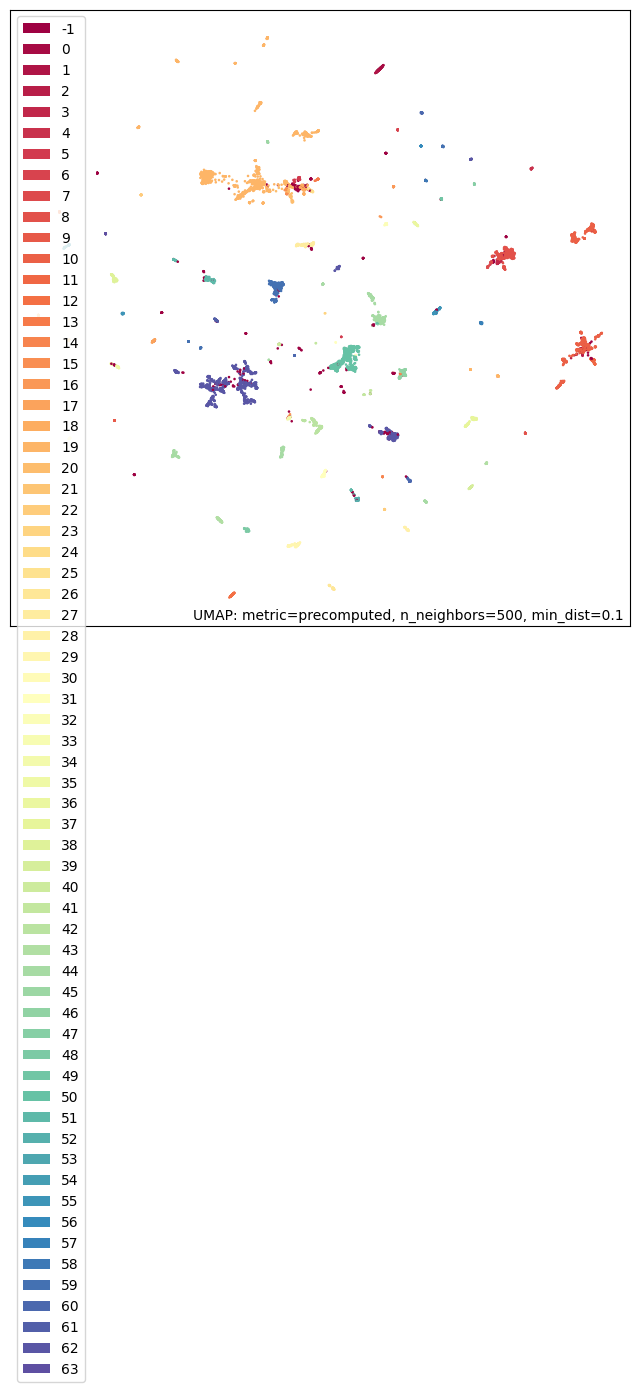

In [28]:
# Plot the UMAP embedding
umap.plot.points(umap_model, labels=clusterer.labels_)

In [21]:
# Initialize k-means clustering
kmeans = cluster.KMeans(n_clusters=max(clusterer.labels_)+1, random_state=42)

# Fit the k-means model to the UMAP embedding
kmeans.fit_predict(u)

array([62, 62, 42, ..., 27, 36, 62], shape=(18952,), dtype=int32)

<Axes: >

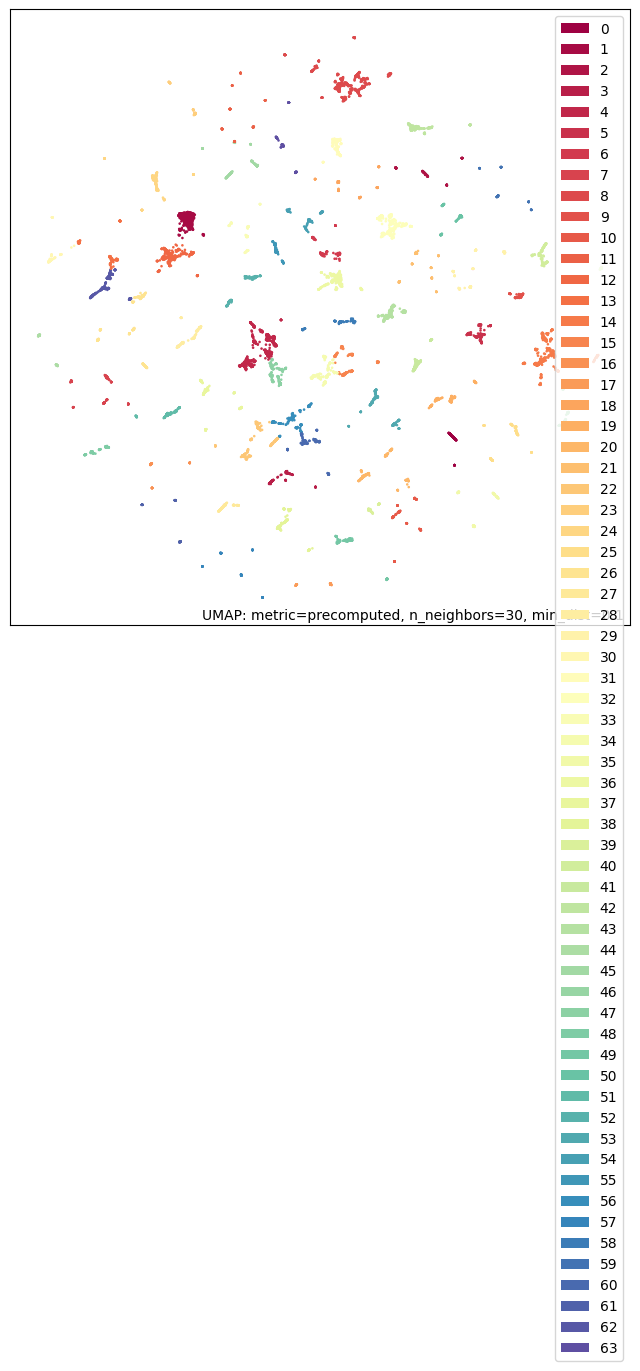

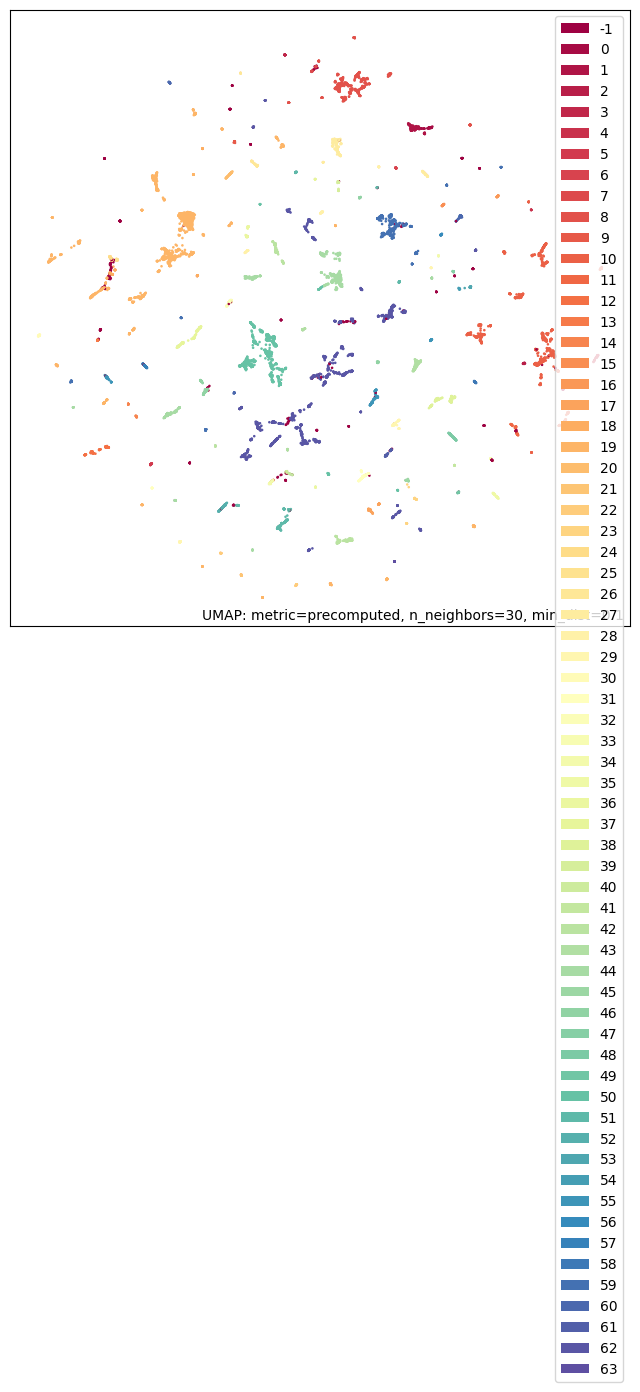

In [22]:
# Plot the k-means clustering results
umap.plot.points(umap_model, labels=kmeans.labels_)

# Compare to the HDBSCAN clustering results
umap.plot.points(umap_model, labels=clusterer.labels_)


In [23]:
# Get the number of samples in each k-means cluster
kmeans_cluster_counts = pd.Series(kmeans.labels_).value_counts().sort_index()
# Print the number of samples in each k-means cluster
print("Number of samples in each k-means cluster:") 
with pd.option_context('display.max_rows', None):
    print(kmeans_cluster_counts)

Number of samples in each k-means cluster:
0     222
1     897
2     176
3     210
4     872
5     292
6     301
7     249
8     851
9     176
10    215
11    130
12    571
13    258
14    714
15    355
16     80
17     78
18    170
19    319
20    367
21    142
22    421
23    144
24    386
25    178
26    410
27    212
28    282
29    242
30    154
31    262
32    523
33    180
34    343
35    231
36    593
37    286
38    324
39    134
40    335
41    303
42    335
43    437
44    114
45    241
46    149
47    316
48    196
49    320
50    166
51    240
52    283
53    311
54    282
55    193
56    324
57    107
58    237
59     84
60    314
61    125
62    392
63    198
Name: count, dtype: int64


In [24]:
# Find the point in each k-means cluster that is closest to the cluster centroid
kmeans_cluster_centers = []
for cluster_label in np.unique(kmeans.labels_):
    cluster_points = np.where(kmeans.labels_ == cluster_label)[0]
    centroid = kmeans.cluster_centers_[cluster_label]
    closest_index = cluster_points[np.argmin(np.linalg.norm(u[cluster_points] - centroid, axis=1))]
    kmeans_cluster_centers.append(closest_index)


In [32]:
# Try k-medioids clustering

# Set k to be the number of HDBSCAN clusters
k = max(clusterer.labels_)+1

kmed = KMedoids(
    n_clusters=k,
    metric='precomputed',
    method='alternate',
    init='k-medoids++',
    max_iter=300,
    random_state=42
)

labels = kmed.fit_predict(distance_matrix)
score = silhouette_score(distance_matrix, labels, metric='precomputed')

print(f"Silhouette score: {score:.4f}")
print(f"Medoid indices: {kmed.medoid_indices_}")

/project/60004/ybrooks/lineage_specific_markers/envs/jupyter/lib/python3.11/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


Silhouette score: 0.6022
Medoid indices: [15930 17980 16946   661 11401  6344  6144 12025 14571 16526  8563  1529
 14181 17800  4105 15393 14984 17226 18060  1350 18507  7859  4767 15174
 11465 16366    83  4758 13264 13565 10210 17744 10469  3387 13281  4534
 13143 13487  4552 11751 16928 14558 18366 18527 14251 12249 15413  2551
 16152 13448  4532  8660   216  3371  5985 15402  3751   182 12133  8145
  5936 18274   287 13699]


In [33]:
# Get the number of samples in each k-medoids cluster
kmed_cluster_counts = pd.Series(kmed.labels_).value_counts().sort_index()
# Print the number of samples in each k-means cluster
print("Number of samples in each k-means cluster:") 
with pd.option_context('display.max_rows', None):
    print(kmed_cluster_counts)

Number of samples in each k-means cluster:
0     3212
1     1749
2     1058
3      796
4     1252
5      312
6      179
7      299
8     1251
9      191
10     484
11     220
12     207
13     255
14     278
15     138
16     292
17     362
18      64
19      64
20     134
21     196
22     213
23     104
24     174
25     244
26     113
27      45
28     204
29       2
30     516
31     658
32     123
33      38
34       1
35      42
36     146
37     114
38      47
39     159
40      43
41      57
42      34
43      66
44     103
45       7
46      30
47      34
48      71
49      65
50       9
51      61
52     126
53     112
54     100
55      71
56      74
57     172
58       6
59      37
60     393
61      20
62     134
63    1191
Name: count, dtype: int64


In [35]:
# Load sample ids corresponding to the samples in the distance matrix
sample_ids = np.loadtxt(SAMPLE_FILE, dtype=str)

# Save the ids of HDBSCAN cluster centers to a text file
hdbscan_cluster_center_ids = sample_ids[cluster_centers]
np.savetxt(repo_root / 'analysis/mash/clustering/hdbscan_cluster_centers.txt', hdbscan_cluster_center_ids, fmt='%s')